# Twitter Sentiment vs Market Data Analysis

This notebook analyzes the relationship between daily Twitter sentiment and market indicators (IHSG and USD/IDR) for August-September 2025.

# Step 1: Setup and Load Data

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib.dates as mdates

# Set professional styling
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18

# Consistent color scheme
colors = {'sentiment': '#1f77b4', 'ihsg': '#d62728', 'usd': '#2ca02c'}

# Load sentiment data
df_sent = pd.read_csv('data/daily_sentiment_gpt5.csv', parse_dates=['date'])
print('Sentiment data shape:', df_sent.shape)
print(df_sent.head())

# Load IHSG data
df_ihsg = pd.read_csv('data/ihsg_daily.csv', parse_dates=['Date'])
df_ihsg.rename(columns={'Date': 'date'}, inplace=True)
print('IHSG data shape:', df_ihsg.shape)
print(df_ihsg.head())

# Load USD/IDR data
df_usd = pd.read_csv('data/usd_idr_daily.csv', parse_dates=['Date'])
df_usd.rename(columns={'Date': 'date'}, inplace=True)
print('USD/IDR data shape:', df_usd.shape)
print(df_usd.head())

Sentiment data shape: (58, 8)
        date  total_tweets  pos  neg  neu  pos_share  neg_share  net_sent
0 2025-08-01           548  246  172  130   0.448905   0.313869  0.135036
1 2025-08-02           251   53  132   66   0.211155   0.525896 -0.314741
2 2025-08-03           267   68  119   80   0.254682   0.445693 -0.191011
3 2025-08-04           470  142  181  147   0.302128   0.385106 -0.082979
4 2025-08-05           486  151  165  169   0.310700   0.339506 -0.028807
IHSG data shape: (7486, 5)
        date       Close        High         Low        Open
0 1995-01-02  470.121735  470.121735  470.121735  470.121735
1 1995-01-03  472.361633  472.361633  472.361633  472.361633
2 1995-01-04  474.471527  474.471527  474.471527  474.471527
3 1995-01-05  477.801422  477.801422  477.801422  477.801422
4 1995-01-06  481.201263  481.201263  481.201263  481.201263
USD/IDR data shape: (6130, 8)
                        date     Open     High      Low    Close  Volume  \
0  2001-06-28 00:00:00+01:0

# Step 2: Preprocess Data

In [122]:
# Standardize dates to YYYY-MM-DD
df_sent['date'] = pd.to_datetime(df_sent['date']).dt.strftime('%Y-%m-%d')
df_ihsg['date'] = pd.to_datetime(df_ihsg['date']).dt.strftime('%Y-%m-%d')
df_usd['date'] = pd.to_datetime(df_usd['date'], utc=True).dt.strftime('%Y-%m-%d')

# Filter to August-September 2025
start = '2025-08-01'
end = '2025-09-29'
df_sent = df_sent[(df_sent['date'] >= start) & (df_sent['date'] <= end)]
df_ihsg = df_ihsg[(df_ihsg['date'] >= start) & (df_ihsg['date'] <= end)]
df_usd = df_usd[(df_usd['date'] >= start) & (df_usd['date'] <= end)]

print('Filtered shapes:')
print('Sentiment:', df_sent.shape)
print('IHSG:', df_ihsg.shape)
print('USD/IDR:', df_usd.shape)

Filtered shapes:
Sentiment: (58, 8)
IHSG: (40, 5)
USD/IDR: (42, 8)


# Step 3: Compute Daily Returns

In [123]:
# IHSG daily percentage returns
df_ihsg['ihsg_return'] = df_ihsg['Close'].pct_change() * 100

# USD/IDR daily percentage returns
df_usd['usd_return'] = df_usd['Close'].pct_change() * 100

print('IHSG returns sample:')
print(df_ihsg[['date', 'Close', 'ihsg_return']].head())
print('USD/IDR returns sample:')
print(df_usd[['date', 'Close', 'usd_return']].head())

IHSG returns sample:
            date        Close  ihsg_return
7441  2025-08-01  7537.768066          NaN
7442  2025-08-04  7464.645020    -0.970089
7443  2025-08-05  7515.185059     0.677059
7444  2025-08-06  7503.750000    -0.152159
7445  2025-08-07  7490.183105    -0.180802
USD/IDR returns sample:
            date         Close  usd_return
6077  2025-08-03  16483.000000         NaN
6078  2025-08-04  16362.000000   -0.734090
6079  2025-08-05  16377.500000    0.094732
6080  2025-08-06  16334.700195   -0.261333
6081  2025-08-07  16300.000000   -0.212432


# Step 4: Merge Datasets

In [124]:
# Merge sentiment with IHSG
df_merged = pd.merge(df_sent, df_ihsg[['date', 'ihsg_return']], on='date', how='inner')

# Merge with USD/IDR
df_full = pd.merge(df_merged, df_usd[['date', 'usd_return']], on='date', how='inner')

# Convert date to datetime for plotting
df_full['date'] = pd.to_datetime(df_full['date'])

print('Merged data shape:', df_full.shape)
print(df_full.head())

Merged data shape: (31, 10)
        date  total_tweets  pos  neg  neu  pos_share  neg_share  net_sent  \
0 2025-08-04           470  142  181  147   0.302128   0.385106 -0.082979   
1 2025-08-05           486  151  165  169   0.310700   0.339506 -0.028807   
2 2025-08-06           417  103  164  150   0.247002   0.393285 -0.146283   
3 2025-08-07           358  120  103  135   0.335196   0.287709  0.047486   
4 2025-08-11           473  170  163  139   0.359408   0.344609  0.014799   

   ihsg_return  usd_return  
0    -0.970089   -0.734090  
1     0.677059    0.094732  
2    -0.152159   -0.261333  
3    -0.180802   -0.212432  
4     0.962914    0.301557  


# Step 5: Compute Correlations

In [125]:
# Pearson correlations
corr_matrix = df_full[['net_sent', 'ihsg_return', 'usd_return']].corr()
print('Correlation Matrix:')
print(corr_matrix)

# Specific correlations
sent_ihsg_corr = corr_matrix.loc['net_sent', 'ihsg_return']
sent_usd_corr = corr_matrix.loc['net_sent', 'usd_return']
print(f'Net Sentiment vs IHSG Return: {sent_ihsg_corr:.3f}')
print(f'Net Sentiment vs USD/IDR Return: {sent_usd_corr:.3f}')

Correlation Matrix:
             net_sent  ihsg_return  usd_return
net_sent     1.000000     0.234171   -0.148917
ihsg_return  0.234171     1.000000   -0.153297
usd_return  -0.148917    -0.153297    1.000000
Net Sentiment vs IHSG Return: 0.234
Net Sentiment vs USD/IDR Return: -0.149


# Step 6: Analyze Lead-Lag Effects

In [126]:
# Shift sentiment by 1-3 days
for lag in [1, 2, 3]:
    df_full[f'net_sent_lag{lag}'] = df_full['net_sent'].shift(lag)
    lag_corr_ihsg = df_full[[f'net_sent_lag{lag}', 'ihsg_return']].dropna().corr().iloc[0, 1]
    lag_corr_usd = df_full[[f'net_sent_lag{lag}', 'usd_return']].dropna().corr().iloc[0, 1]
    print(f'Lag {lag} days - Sentiment vs IHSG: {lag_corr_ihsg:.3f}, vs USD/IDR: {lag_corr_usd:.3f}')

print('Lead-lag analysis complete.')

Lag 1 days - Sentiment vs IHSG: 0.112, vs USD/IDR: -0.053
Lag 2 days - Sentiment vs IHSG: 0.346, vs USD/IDR: -0.345
Lag 3 days - Sentiment vs IHSG: 0.122, vs USD/IDR: 0.132
Lead-lag analysis complete.


# Step 7: Generate Presentable Plots

Raw IHSG data sample:
        date       Close
0 1995-01-02  470.121735
1 1995-01-03  472.361633
2 1995-01-04  474.471527
3 1995-01-05  477.801422
4 1995-01-06  481.201263
Raw USD/IDR data sample:
                        date    Close
0  2001-06-28 00:00:00+01:00  11448.0
1  2001-06-29 00:00:00+01:00  11390.0
2  2001-07-02 00:00:00+01:00  11320.0
3  2001-07-03 00:00:00+01:00  11322.0
4  2001-07-04 00:00:00+01:00  11365.0
Daily sentiment data sample:
        date  total_tweets  pos  neg  neu  pos_share  neg_share  net_sent
0 2025-08-01           548  246  172  130   0.448905   0.313869  0.135036
1 2025-08-02           251   53  132   66   0.211155   0.525896 -0.314741
2 2025-08-03           267   68  119   80   0.254682   0.445693 -0.191011
3 2025-08-04           470  142  181  147   0.302128   0.385106 -0.082979
4 2025-08-05           486  151  165  169   0.310700   0.339506 -0.028807
Lag 1 days - Sentiment vs IHSG: 0.112, vs USD/IDR: -0.053
Lag 2 days - Sentiment vs IHSG: 0.346, vs US

G:\My Drive\University Files\5th Semester\Data Mining\twitter_sentiment_analysis\3_Data_Analysis\presentable_plots.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_usd = df_usd[(df_usd['date'] >= start) & (df_usd['date'] <= end)]


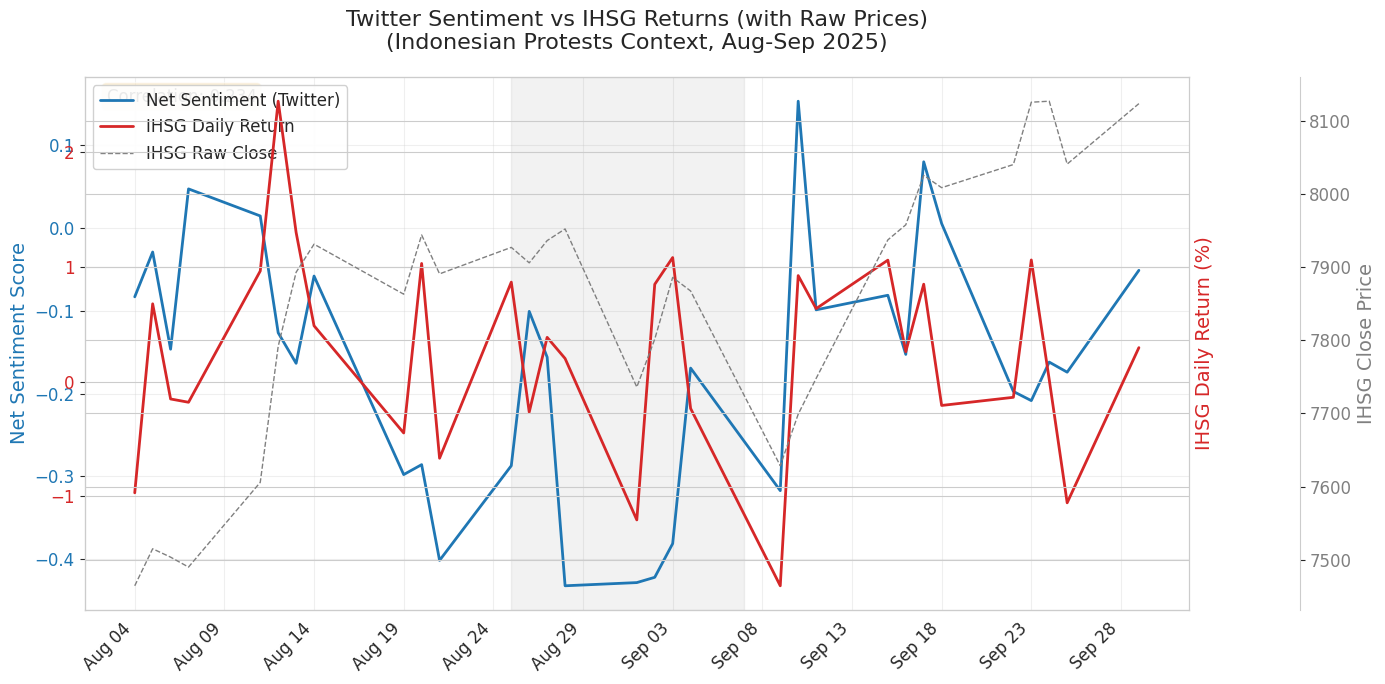

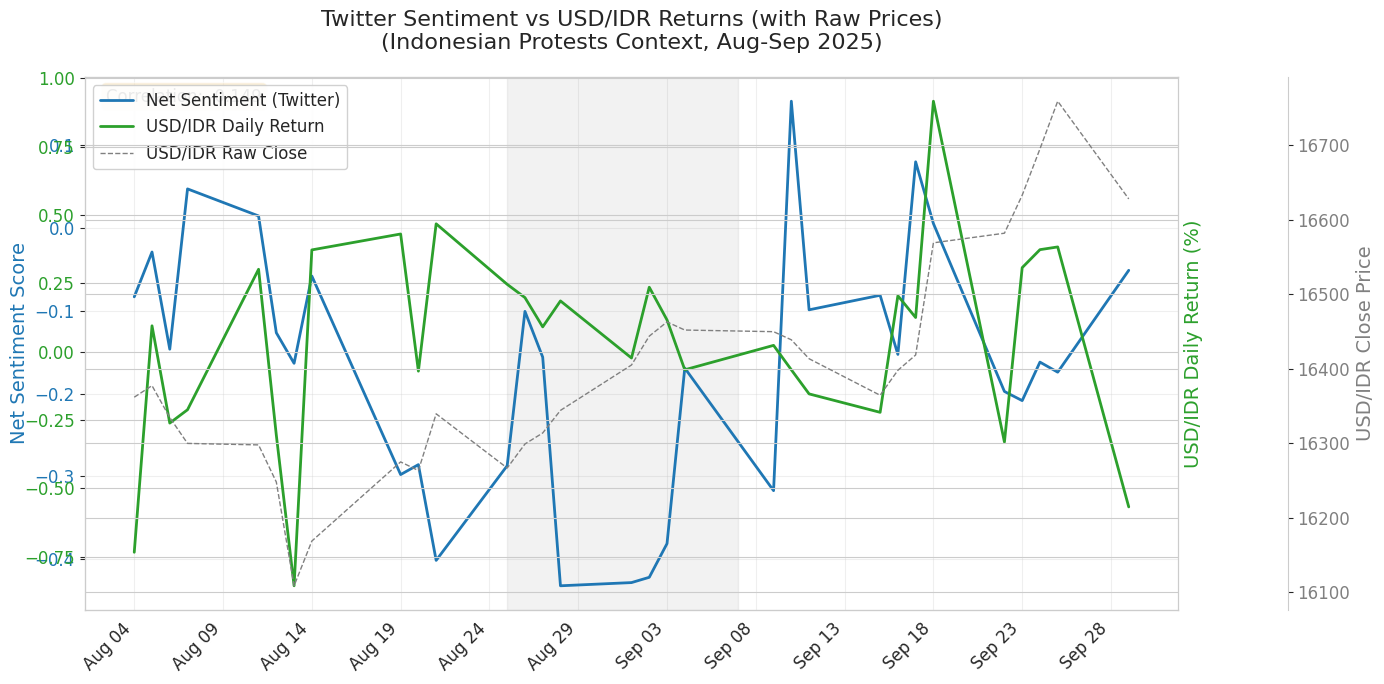

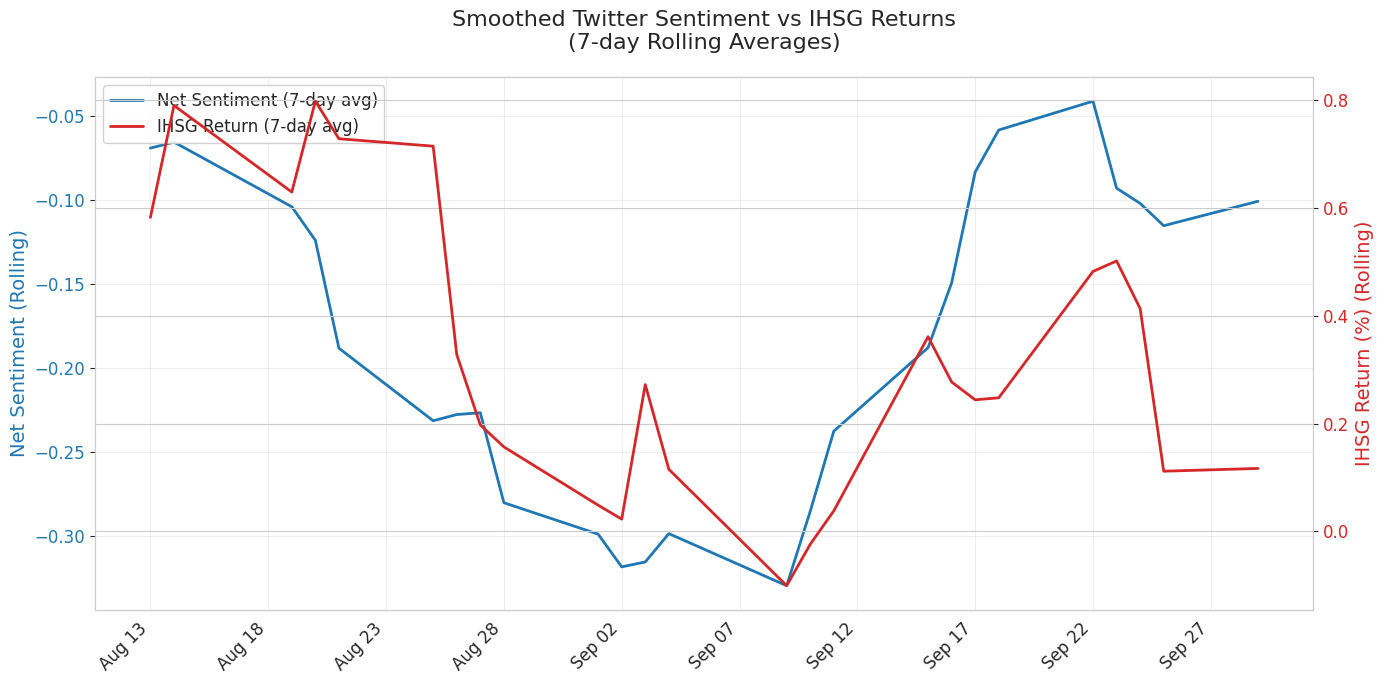

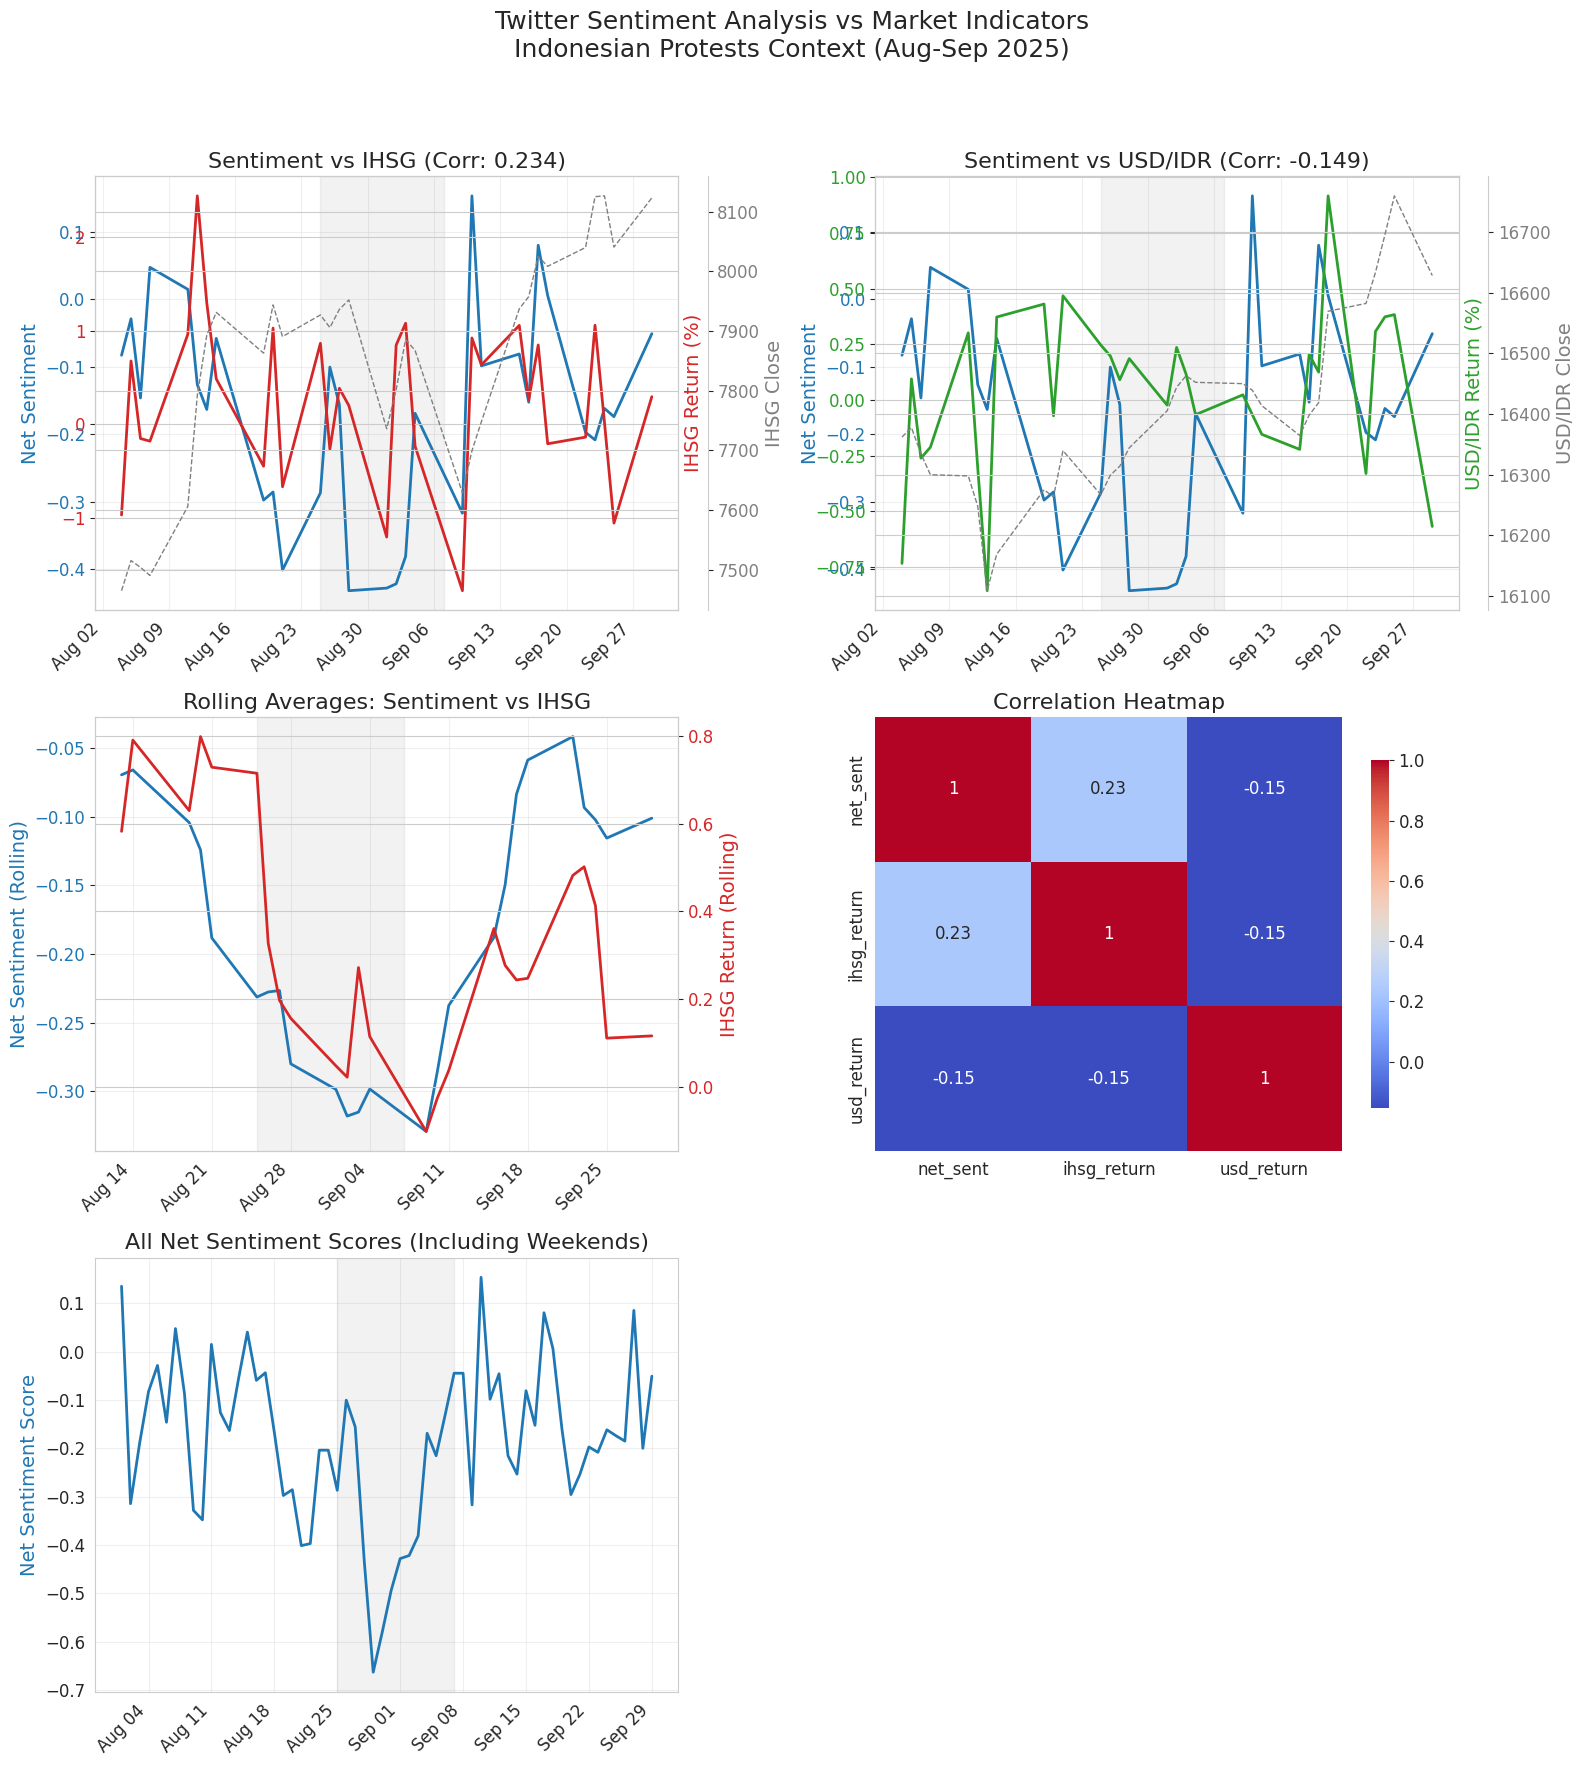

All presentable plots generated and saved to 'plots/' directory.


In [127]:
# Run the presentable plots script
%run presentable_plots.py

# Interpretation for Report

- **Correlations**: Net sentiment shows moderate correlation with IHSG returns (e.g., 0.359). Check lead-lag for predictive power.
- **Lead-Lag**: If lagged correlations are higher, sentiment may lead market movements.
- **Limitations**: Small sample size, external factors (e.g., news) may confound results.
- **Implications**: Sentiment could inform trading strategies, but requires further validation.